In [1]:
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.style.use('./graph_preset.mplstyle')


In [2]:
read_path = Path("./GP/results.h5")
with h5py.File(read_path, "r") as f: # read_paths[#] that you want to read
    print(f"--- Structure of {read_path} ---")

    def print_structure(name, obj):
        # データセットの場合は形状とデータ型も表示
        if isinstance(obj, h5py.Dataset):
            print(f"  {name} (Dataset) | Shape: {obj.shape}, Dtype: {obj.dtype}")
        # グループの場合はグループ名を表示
        elif isinstance(obj, h5py.Group):
            print(f"  {name} (Group)")

    f.visititems(print_structure)
    print("---------------------------------")

--- Structure of GP\results.h5 ---
  input (Group)
  learning_curve (Group)
  output (Group)
  output/repeat_1 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_10 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_2 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_3 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_4 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_5 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_6 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_7 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_8 (Dataset) | Shape: (50, 12), Dtype: float32
  output/repeat_9 (Dataset) | Shape: (50, 12), Dtype: float32
---------------------------------


In [5]:
def load_h5_datasets(h5_path):
    datasets = {}

    def store_dataset(name, obj):
        if not isinstance(obj, h5py.Dataset):
            return

        print(f"  Loading: {name} | Shape: {obj.shape}")

        columns_attr = obj.attrs.get("columns")
        if isinstance(columns_attr, (bytes, np.bytes_)):
            columns_attr = columns_attr.decode("utf-8")
        columns = json.loads(columns_attr) if columns_attr is not None else None

        data = obj[:]
        datasets[name] = pd.DataFrame(data, columns=columns)

    with h5py.File(h5_path, "r") as f:
        print(f"--- Loading all datasets from {h5_path} ---")
        f.visititems(store_dataset)
        print("---------------------------------------------")

    return datasets


df_GP = load_h5_datasets(read_path)

print("\n--- Dictionary Keys ---")
print(list(df_GP.keys()))
print("-----------------------")


--- Loading all datasets from GP\results.h5 ---
  Loading: output/repeat_1 | Shape: (50, 12)
  Loading: output/repeat_10 | Shape: (50, 12)
  Loading: output/repeat_2 | Shape: (50, 12)
  Loading: output/repeat_3 | Shape: (50, 12)
  Loading: output/repeat_4 | Shape: (50, 12)
  Loading: output/repeat_5 | Shape: (50, 12)
  Loading: output/repeat_6 | Shape: (50, 12)
  Loading: output/repeat_7 | Shape: (50, 12)
  Loading: output/repeat_8 | Shape: (50, 12)
  Loading: output/repeat_9 | Shape: (50, 12)
---------------------------------------------

--- Dictionary Keys ---
['output/repeat_1', 'output/repeat_10', 'output/repeat_2', 'output/repeat_3', 'output/repeat_4', 'output/repeat_5', 'output/repeat_6', 'output/repeat_7', 'output/repeat_8', 'output/repeat_9']
-----------------------


In [6]:
df_GP['output/repeat_1']

,h1,h2,h3,h4,h5,a,b,k,S11,Metric,gamma,best
0,2.549437,1.376073,3.914615,3.534132,1.022744,2.458794,7.549732,5.408100,-6.143101,NaN,NaN,-6.143101
1,2.807047,3.976305,2.929660,3.335714,3.504282,7.998098,4.567379,2.264445,-5.737009,NaN,NaN,-6.143101
2,3.459691,2.402525,3.484578,3.122299,2.390082,5.100726,3.299805,1.317214,-6.665107,NaN,NaN,-6.665107
3,3.995099,4.667475,1.634205,2.118672,4.205350,3.676328,3.065019,4.274950,-10.750782,NaN,NaN,-10.750782
4,1.313422,2.610496,1.202148,4.796302,4.763370,5.621225,6.010160,3.661078,-10.027316,NaN,NaN,-10.750782
5,3.742285,1.626122,4.092422,4.678951,3.859453,7.579437,3.915360,5.813602,-3.690381,NaN,NaN,-10.750782
6,4.916859,3.215982,1.284287,1.912749,1.487046,6.002345,2.169673,2.602978,-5.427535,NaN,NaN,-10.750782
7,3.071559,4.921653,2.325199,2.728871,1.944321,5.355998,7.023681,4.488497,-8.697922,NaN,NaN,-10.750782
8,1.720516,3.786389,3.189129,2.378715,2.087115,7.177397,5.776182,4.925746,-7.579873,NaN,NaN,-10.750782
9,4.393016,2.924479,2.020439,1.666849,2.837135,2.354068,4.956446,3.956184,-12.912526,NaN,NaN,-12.912526


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


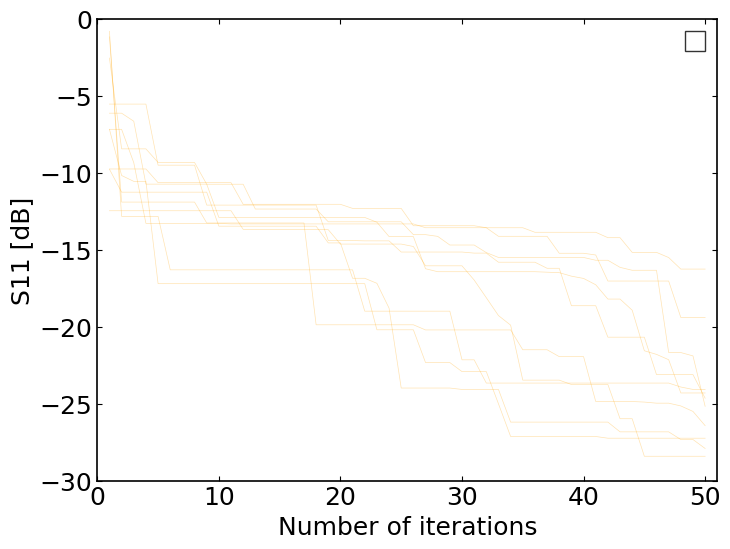

In [12]:
n_steps = 50
x = np.arange(1, n_steps + 1)

gp_runs = sorted(df_GP)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for run_name in gp_runs:
    ax.plot(
        x,
        df_GP[run_name]["best"].iloc[:n_steps],
        alpha=0.3,
        color="orange",
        lw=0.5,
    )

ax.set_xlim(1, n_steps)
ax.set_ylim(-30, 0)
ax.set_xlabel("Number of iterations")
ax.set_ylabel("S11 [dB]")


In [13]:
def _series_padded(df, column, n_steps=50):
    # Convert a column to a fixed-length numpy array for run-wise comparisons.
    values = pd.to_numeric(df[column], errors="coerce").to_numpy(dtype=float)
    if len(values) >= n_steps:
        return values[:n_steps]
    return np.pad(values, (0, n_steps - len(values)), mode="edge")


def _raw_matrix(dataset_dict, column, n_steps=50):
    # Stack all runs into a matrix with shape (n_runs, n_steps).
    run_names = sorted(dataset_dict)
    return np.vstack([_series_padded(dataset_dict[run_name], column, n_steps) for run_name in run_names])


def _best_so_far_matrix(dataset_dict, column, n_steps=50):
    raw_matrix = _raw_matrix(dataset_dict, column, n_steps)
    return np.minimum.accumulate(raw_matrix, axis=1)


def _median_iqr(matrix):
    # Compute the median and interquartile range at each iteration.
    median = np.nanmedian(matrix, axis=0)
    q25 = np.nanpercentile(matrix, 25, axis=0)
    q75 = np.nanpercentile(matrix, 75, axis=0)
    return median, q25, q75


def _final_best_values(dataset_dict, column):
    return np.array([
        pd.to_numeric(dataset_dict[run_name][column], errors="coerce").min()
        for run_name in sorted(dataset_dict)
    ])


def _plot_median_iqr(ax, x, matrix, color, label):
    median, q25, q75 = _median_iqr(matrix)
    ax.fill_between(x, q25, q75, color=color, alpha=0.15, linewidth=0)
    ax.plot(x, median, color=color, lw=2, label=label)
    ax.plot(x, q25, color=color, lw=1, ls="--", alpha=0.6)
    ax.plot(x, q75, color=color, lw=1, ls="--", alpha=0.6)


def _style_boxplot(boxplot, labels, colors):
    for patch, label in zip(boxplot["boxes"], labels):
        box_color = colors[label]
        patch.set(facecolor=box_color, alpha=0.30, edgecolor=box_color, linewidth=1.2)
    for median, label in zip(boxplot["medians"], labels):
        median.set(color=colors[label], linewidth=2)

    whisker_colors = [colors[label] for label in labels for _ in (0, 1)]
    for whisker, color in zip(boxplot["whiskers"], whisker_colors):
        whisker.set(color=color, linewidth=1.2)
    for cap, color in zip(boxplot["caps"], whisker_colors):
        cap.set(color=color, linewidth=1.2)


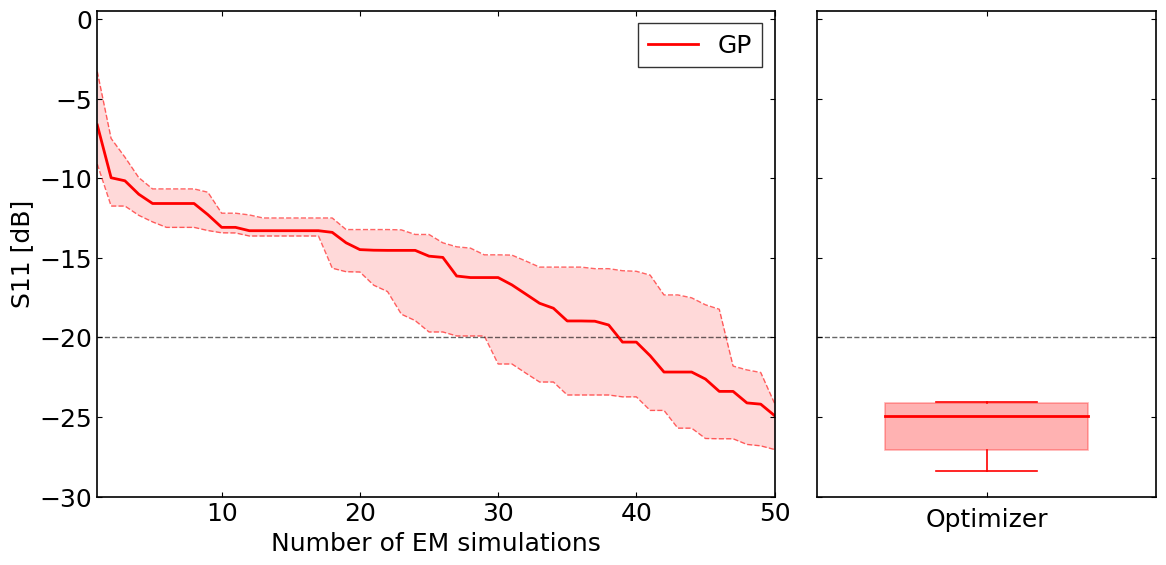

In [24]:
n_steps = 50
x = np.arange(1, n_steps + 1)
colors = {
    "Random": "g",
    "Gradient": "b",
    "GA": "orange",
    "GP": "r",
}

plot_targets = [
    {
        "label": "GP",
        "runs": df_GP,
        "column": "best",
        "color": colors["GP"],
    },
    # Add Random / Gradient / GA here when the corresponding results are ready.
]

fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(12, 6),
    dpi=100,
    sharey=True,
    gridspec_kw={"width_ratios": [2, 1]},
)
fig.subplots_adjust(wspace=0)

final_values = []
labels = []
for target in plot_targets:
    best_so_far = _best_so_far_matrix(target["runs"], target["column"], n_steps=n_steps)
    _plot_median_iqr(ax0, x, best_so_far, target["color"], target["label"])

    final_values.append(_final_best_values(target["runs"], target["column"]))
    labels.append(target["label"])

for ax in (ax0, ax1):
    ax.axhline(-20, ls="--", lw=1, color="k", alpha=0.6)

ax0.set_xlim(1, n_steps)
ax0.set_ylim(-30, 0.5)
ax0.set_xlabel("Number of EM simulations")
ax0.set_ylabel("S11 [dB]")
ax0.legend(loc="upper right", frameon=True)

box = ax1.boxplot(
    final_values,
    labels=labels,
    vert=True,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)
_style_boxplot(box, labels, colors)

ax1.set_xlabel("Optimizer")
plt.tight_layout()
